# MLP — classificação dos estados do jogo da velha

Uma **MLP (Multilayer Perceptron)** é uma rede neural com camadas de neurônios.
Neste experimento, ela recebe as características de um tabuleiro e aprende a classificá-lo
em **Tem jogo**, **Jogador X venceu**, **Jogador O venceu** ou **Empate**.
Ela verifica o estado; não escolhe jogadas.

Seguimos a divisão de dados e as médias macro usadas nos notebooks de
[k-NN](../knn/knn.ipynb) e [árvore de decisão](../arvoreDecisao/arvore_decisao.ipynb).
As duas representações são comparadas com os mesmos exemplos, sem refazer a amostragem.
O procedimento experimental é: carregar dados → padronizar → escolher parâmetros pela validação →
avaliar no teste → documentar resultados e custo.

Execute as células na ordem. As explicações e os resultados fazem parte da documentação
do experimento; os arquivos exportados ficam em `mlp/resultados/`.

## 1. Importar as bibliotecas

`pandas` organiza tabelas; `MLPClassifier` implementa a rede; `StandardScaler` padroniza
as características; `Pipeline` mantém o pré-processamento junto do modelo.
As métricas e os gráficos permitem avaliar a classificação. `time` mede o custo.
`warnings` registra problemas de convergência e `joblib` salva o modelo treinado.

In [1]:
import hashlib
import json
import platform
import time
import warnings
from itertools import product
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

## 2. Definir caminhos e classes

A semente 42 torna o experimento reproduzível no mesmo ambiente. Procuramos a pasta
do projeto para que o notebook funcione tanto a partir da raiz quanto de sua própria pasta.
Registramos as versões, pois bibliotecas e computadores diferentes podem mudar os tempos
e, eventualmente, detalhes numéricos do treinamento.

In [2]:
SEED = 42
CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {
    "abordagem_1": "A1 (tabuleiro)",
    "abordagem_2": "A2 (características)",
}

RAIZ = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents]
     if (pasta / "dataset/processado/abordagem_1/treino.csv").is_file()),
    None,
)
if RAIZ is None:
    raise FileNotFoundError("Abra o notebook dentro da pasta deste projeto.")
BASE = RAIZ / "dataset/processado"
PASTA_RESULTADOS = BASE / "mlp/resultados"
figuras = {}

versoes = {
    "python": platform.python_version(), "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "matplotlib": matplotlib.__version__,
    "numpy": np.__version__, "joblib": joblib.__version__,
}
print("Pasta dos dados:", BASE)
print("Versões:", versoes)

Pasta dos dados: /Users/amandacwilmsen/Desktop/tic tac toe/ai-tic-tac-toe/dataset/processado
Versões: {'python': '3.13.13', 'pandas': '3.0.5', 'scikit_learn': '1.9.0', 'matplotlib': '3.11.2', 'numpy': '2.5.2', 'joblib': '1.5.3'}


## 3. Carregar as duas abordagens

`X` contém as entradas e `y` contém a resposta correta, chamada de **rótulo**.
Removemos `estado` de `X` para não entregar a resposta à rede, e removemos
`id_tabuleiro`, que serve somente para identificar os exemplos.

A abordagem 1 tem nove casas numéricas (`vazio=0`, `X=1`, `O=-1`). A abordagem 2 tem
15 características: contagens de X/O, nove indicadores de ocupação, alinhamentos com
duas marcas de cada jogador, casas vazias e próximo turno hipotético.
Os CSVs já estão tratados; não geramos outros dados nem alteramos suas divisões.

In [3]:
dados = {}
arquivos_entrada = []
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        caminho = BASE / ab / f"{conjunto}.csv"
        arquivos_entrada.append(caminho)
        df = pd.read_csv(caminho)
        assert not df.isna().any().any(), f"Valor ausente em {caminho}"
        assert set(df["estado"]) == set(CLASSES), f"Classes inesperadas em {caminho}"
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].to_numpy()
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for sufixo in ["train", "val", "test"]:
    assert dados["abordagem_1"][f"ids_{sufixo}"].equals(dados["abordagem_2"][f"ids_{sufixo}"])
    assert np.array_equal(dados["abordagem_1"][f"y_{sufixo}"], dados["abordagem_2"][f"y_{sufixo}"])

for ab, d in dados.items():
    print(abordagens[ab])
    for sufixo in ["train", "val", "test"]:
        print(f"  X_{sufixo}: {d[f'X_{sufixo}'].shape}; y_{sufixo}: {d[f'y_{sufixo}'].shape}")

contagens = pd.DataFrame({
    nome: pd.Series(dados["abordagem_1"][f"y_{sufixo}"]).value_counts().reindex(CLASSES)
    for nome, sufixo in [("Treino", "train"), ("Validação", "val"), ("Teste", "test")]
})
contagens

A1 (tabuleiro)
  X_train: (560, 9); y_train: (560,)
  X_val: (92, 9); y_val: (92,)
  X_test: (93, 9); y_test: (93,)
A2 (características)
  X_train: (560, 15); y_train: (560,)
  X_val: (92, 15); y_val: (92,)
  X_test: (93, 15); y_test: (93,)


,Treino,Validação,Teste
Tem jogo,140,30,30
Jogador X venceu,140,30,30
Jogador O venceu,140,30,30
Empate,140,2,3


## 4. Conferir a separação dos conjuntos

O treino tem 560 linhas, mas apenas 431 tabuleiros diferentes: os empates foram repetidos
somente no treino para equilibrar as classes. Isso não aumenta a diversidade dos empates.
Nenhum mesmo ID pode passar de um conjunto para outro.

**Limitações já conhecidas:** há apenas dois empates na validação e três no teste;
a avaliação dessa classe é sensível a cada erro. Rotações/reflexões equivalentes podem
estar em conjuntos diferentes. Na abordagem 2, cinco grupos de tabuleiros distintos
do treino têm características iguais e rótulos diferentes. A rede não consegue distinguir
respostas diferentes quando recebe exatamente a mesma entrada.

In [4]:
for ab, d in dados.items():
    ids = {s: set(d[f"ids_{s}"]) for s in ["train", "val", "test"]}
    assert not (ids["train"] & ids["val"])
    assert not (ids["train"] & ids["test"])
    assert not (ids["val"] & ids["test"])
    assert d["ids_val"].is_unique and d["ids_test"].is_unique
    print(f"{abordagens[ab]}: conjuntos sem IDs compartilhados; "
          f"{len(d['ids_train'])} linhas de treino e {len(ids['train'])} IDs distintos.")

A1 (tabuleiro): conjuntos sem IDs compartilhados; 560 linhas de treino e 431 IDs distintos.
A2 (características): conjuntos sem IDs compartilhados; 560 linhas de treino e 431 IDs distintos.


## 5. Definir as métricas de classificação

- **Acurácia:** proporção de previsões corretas entre todos os exemplos avaliados.
- **Precisão (precision):** entre as previsões de uma classe, proporção de exemplos que pertencem a ela.
- **Sensibilidade (recall):** entre os exemplos reais de uma classe, proporção reconhecida pelo modelo.
- **F1 (F-measure):** média harmônica entre precisão e recall, calculada por `2 × precisão × recall / (precisão + recall)`.

Para precisão, recall e F1, adotamos a média **macro**: calculamos a métrica separadamente
para cada uma das quatro classes e, depois, sua média aritmética. Cada classe recebe o
mesmo peso, inclusive **Empate**, que possui poucos exemplos. O F1 macro é a média dos
F1 por classe; ele não é calculado a partir das médias de precisão e recall.

Quando a divisão de uma métrica é indefinida, `zero_division=0` atribui zero.
A acurácia é calculada sobre o total de exemplos. A seleção dos parâmetros utiliza
F1 macro de validação, enquanto o teste é reservado à avaliação das configurações selecionadas.

Referência: [definição de F1 e média macro no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [5]:
def metricas(y_real, y_pred):
    return {
        "acc": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
        "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
        "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
    }

## 6. Entender a MLP e suas escolhas

Cada neurônio combina as entradas usando **pesos** e um **viés**, e aplica uma função
de ativação. As camadas intermediárias (ocultas) permitem aprender relações não lineares,
como combinações de marcas em diferentes casas. Durante o treino, a **retropropagação**
calcula como os pesos influenciam o erro; o otimizador usa essa informação para ajustá-los.

A topologia é escrita como **entradas → camadas ocultas → saídas**. Por exemplo,
`9 → 32 → 4` recebe nove casas, usa uma camada oculta com 32 neurônios e produz quatro
probabilidades de classe. No problema multiclasse, a saída do `MLPClassifier` usa **softmax**;
a previsão é a classe de maior probabilidade. A ordem interna das saídas fica em `classes_`.

Testaremos `relu` (zera valores negativos) e `tanh` (produz valores entre -1 e 1).
O parâmetro **alpha** controla a regularização L2, uma penalização de pesos grandes.
Ela ajuda a limitar a complexidade, mas um valor excessivo pode prejudicar o aprendizado.

Usaremos **L-BFGS**, um otimizador que utiliza informações sobre a curvatura da função
de erro. A documentação indica que ele pode funcionar bem em conjuntos pequenos;
isso justifica a escolha para as 560 linhas de treino, sem garantir que será o melhor em todo problema.
Não ajustamos `learning_rate_init`, porque esse parâmetro não atua com L-BFGS.

Referências: [guia de redes neurais do scikit-learn](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)
e [parâmetros do MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

## 7. Padronizar as entradas sem vazamento de dados

A MLP é sensível à escala das entradas. O `StandardScaler` subtrai a média e divide pelo
desvio padrão de cada característica (uma coluna constante fica em zero).
Aplicamos isso nas duas abordagens, pois usamos o mesmo tipo de rede nos dois casos.

O `Pipeline` ajusta o padronizador **somente no treino**. Ao prever validação e teste,
ele reutiliza essas médias e desvios, sem recalculá-los. Usar os três conjuntos para
calcular a escala revelaria informações dos dados reservados para avaliação.

Fixamos `max_iter=2000`, `max_fun=30000` e `tol=0.0001` para dar espaço à convergência.
São limites e critério de parada do otimizador, não garantia de que todas as redes convergirão.
Não usamos divisão interna para early stopping: temos validação externa e há repetições
de empates no treino, que poderiam aparecer dos dois lados de uma divisão interna.

In [6]:
PARAMETROS_FIXOS = {
    "solver": "lbfgs", "max_iter": 2000, "max_fun": 30000,
    "tol": 1e-4, "random_state": SEED, "early_stopping": False,
}

def criar_modelo(camadas, ativacao, alpha):
    return make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=camadas, activation=ativacao,
                      alpha=alpha, **PARAMETROS_FIXOS),
    )

def numero_parametros(modelo):
    rede = modelo.named_steps["mlpclassifier"]
    return sum(pesos.size for pesos in rede.coefs_) + sum(vies.size for vies in rede.intercepts_)

def ajustar_modelo(modelo, X, y):
    # Uma thread limita o paralelismo durante o ajuste, inclusive nas medições de custo.
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always", ConvergenceWarning)
        with threadpool_limits(limits=1):
            modelo.fit(X, y)
    problemas = [str(aviso.message) for aviso in avisos
                 if issubclass(aviso.category, ConvergenceWarning)]
    return problemas

## 8. Definir a busca de parâmetros antes do teste

Testamos redes pequenas com uma ou duas camadas ocultas, adequadas ao tamanho dos dados.
Uma grade é uma lista de alternativas para cada parâmetro; cada combinação vira um treino.

| Parâmetro | Valores | Motivo |
| --- | --- | --- |
| Camadas ocultas | `(16,)`, `(32,)`, `(64,)`, `(64, 32)` | Comparar capacidade e custo com arquiteturas simples |
| Ativação | `relu`, `tanh` | Comparar duas transformações não lineares |
| Alpha | `0.0001`, `0.01`, `0.1`, `1.0` | Comparar intensidades de regularização L2 |

São **32 combinações por abordagem, 64 ao todo**. A grade é a mesma nas duas abordagens.
A semente fixa controla a inicialização dos pesos; uma única semente não mede toda a
variabilidade possível da rede, o que é uma limitação deste experimento.

In [7]:
lista_camadas = [(16,), (32,), (64,), (64, 32)]
lista_ativacao = ["relu", "tanh"]
lista_alpha = [0.0001, 0.01, 0.1, 1.0]
grade = list(product(lista_camadas, lista_ativacao, lista_alpha))
print(f"{len(grade)} configurações por abordagem; {len(grade) * len(abordagens)} treinos no total.")

32 configurações por abordagem; 64 treinos no total.


## 9. Treinar e selecionar pela validação

Para cada configuração, treinamos apenas com `X_train` e `y_train`, medimos treino e
validação e guardamos o melhor modelo de cada abordagem. **Não usamos o teste nesta busca.**

A seleção prioriza F1 macro de validação; em empate, prioriza acurácia de validação,
depois menos pesos/vieses e depois maior alpha. Se tudo empatar, mantém a primeira
configuração da grade. Esse desempate favorece simplicidade e regularização sem sacrificar
o critério principal. Configurações com aviso de convergência são registradas e não concorrem.

Também guardamos `F1_treino - F1_validação`. Uma diferença grande pode indicar
**overfitting** (ótimo desempenho no treino, dificuldade em exemplos reservados).
Essa diferença é um indício, não um diagnóstico isolado, especialmente com poucos empates.

In [8]:
resultados = []
melhor = {}

for ab, d in dados.items():
    print(f"Treinando {abordagens[ab]}...", flush=True)
    for indice, (camadas, ativacao, alpha) in enumerate(grade, start=1):
        params = {"camadas": camadas, "ativacao": ativacao, "alpha": alpha}
        modelo = criar_modelo(**params)
        inicio = time.perf_counter()
        avisos = ajustar_modelo(modelo, d["X_train"], d["y_train"])
        tempo_ms = (time.perf_counter() - inicio) * 1000
        m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
        m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))
        rede = modelo.named_steps["mlpclassifier"]
        n_params = numero_parametros(modelo)
        resultados.append({
            "codigo_abordagem": ab, "abordagem": abordagens[ab],
            "camadas": str(camadas), "ativacao": ativacao, "alpha": alpha,
            "n_parametros": n_params, "iteracoes": rede.n_iter_, "perda_final": rede.loss_,
            "f1_treino": m_train["f1_macro"], "treino_acc": m_train["acc"],
            "val_acc": m_val["acc"], "val_precision": m_val["precision"],
            "val_recall": m_val["recall"], "val_f1_macro": m_val["f1_macro"],
            "gap_treino_val": m_train["f1_macro"] - m_val["f1_macro"],
            "tempo_busca_treino_ms": tempo_ms, "convergiu": not avisos,
            "avisos": " | ".join(avisos),
        })
        chave = (m_val["f1_macro"], m_val["acc"], -n_params, alpha)
        if not avisos and (ab not in melhor or chave > melhor[ab]["chave"]):
            melhor[ab] = {
                "chave": chave, "modelo": modelo, "params": params,
                "metricas_treino": m_train, "metricas_validacao": m_val,
            }
        if indice % 8 == 0:
            print(f"  {indice}/{len(grade)} configurações concluídas.", flush=True)
    if ab not in melhor:
        raise RuntimeError(f"Nenhuma configuração convergiu para {ab}. Revise a busca antes de avaliar o teste.")

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))
print("Configurações com aviso de convergência:", int((~resultados["convergiu"]).sum()))
resultados.sort_values(
    ["abordagem", "convergiu", "val_f1_macro", "val_acc", "n_parametros", "alpha"],
    ascending=[True, False, False, False, True, False],
).groupby("abordagem", sort=False).head(5).reset_index(drop=True)

Treinando A1 (tabuleiro)...
  8/32 configurações concluídas.
  16/32 configurações concluídas.
  24/32 configurações concluídas.
  32/32 configurações concluídas.
Treinando A2 (características)...
  8/32 configurações concluídas.
  16/32 configurações concluídas.
  24/32 configurações concluídas.
  32/32 configurações concluídas.
Combinações testadas: 64
Configurações com aviso de convergência: 0


,codigo_abordagem,abordagem,camadas,ativacao,alpha,n_parametros,iteracoes,perda_final,f1_treino,treino_acc,val_acc,val_precision,val_recall,val_f1_macro,gap_treino_val,tempo_busca_treino_ms,convergiu,avisos
0,abordagem_1,A1 (tabuleiro),"(64, 32)",relu,1.0000,2852,1906,0.099514,1.000000,1.000000,0.858696,0.897861,0.775000,0.808734,0.191266,1104.171750,True,
1,abordagem_1,A1 (tabuleiro),"(32,)",relu,0.0001,452,52,0.000380,1.000000,1.000000,0.869565,0.788889,0.783333,0.781734,0.218266,45.020875,True,
2,abordagem_1,A1 (tabuleiro),"(64, 32)",relu,0.1000,2852,516,0.013294,1.000000,1.000000,0.869565,0.786688,0.783333,0.778480,0.221520,311.675709,True,
3,abordagem_1,A1 (tabuleiro),"(64,)",relu,1.0000,900,1988,0.189924,1.000000,1.000000,0.869565,0.791422,0.783333,0.776648,0.223352,705.764375,True,
4,abordagem_1,A1 (tabuleiro),"(64,)",relu,0.0100,900,127,0.005454,1.000000,1.000000,0.847826,0.771429,0.766667,0.758846,0.241154,50.771500,True,
5,abordagem_2,A2 (características),"(64, 32)",relu,1.0000,3236,1712,0.068961,0.991031,0.991071,0.934783,0.951322,0.950000,0.949021,0.042011,1042.888334,True,
6,abordagem_2,A2 (características),"(16,)",relu,0.0100,324,914,0.017437,0.991045,0.991071,0.934783,0.951528,0.950000,0.949014,0.042031,182.991458,True,
7,abordagem_2,A2 (características),"(16,)",relu,0.1000,324,1105,0.029323,0.991031,0.991071,0.923913,0.944072,0.941667,0.940276,0.050755,224.662041,True,
8,abordagem_2,A2 (características),"(32,)",relu,0.0100,644,333,0.017487,0.991031,0.991071,0.923913,0.944072,0.941667,0.940276,0.050755,91.969083,True,
9,abordagem_2,A2 (características),"(32,)",tanh,0.0100,644,197,0.017971,0.991031,0.991071,0.923913,0.944072,0.941667,0.940276,0.050755,55.239291,True,


## 10. Registrar as topologias selecionadas

A tabela abaixo mostra a rede efetivamente escolhida em cada abordagem, seu número
de parâmetros e seus resultados de treino/validação. A quantidade de entradas é diferente,
por isso a mesma camada oculta pode ter mais pesos na abordagem 2.

Escolhemos também a abordagem recomendada pelo desempenho **na validação**.
Em empate entre abordagens, usamos a menor quantidade de parâmetros.
As escolhas ficam congeladas antes da avaliação no teste; não juntamos treino e validação
para um novo ajuste, preservando o procedimento dos outros notebooks.

In [9]:
selecao = []
for ab, info in melhor.items():
    modelo = info["modelo"]
    rede = modelo.named_steps["mlpclassifier"]
    topologia = [dados[ab]["X_train"].shape[1], *info["params"]["camadas"], rede.n_outputs_]
    selecao.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "topologia": " → ".join(map(str, topologia)),
        "ativacao": info["params"]["ativacao"], "alpha": info["params"]["alpha"],
        "n_parametros": numero_parametros(modelo),
        "f1_treino": info["metricas_treino"]["f1_macro"],
        "val_acc": info["metricas_validacao"]["acc"],
        "val_f1_macro": info["metricas_validacao"]["f1_macro"],
        "gap_treino_val": info["metricas_treino"]["f1_macro"] - info["metricas_validacao"]["f1_macro"],
    })
    print(f"{abordagens[ab]}: saídas em ordem {list(rede.classes_)}")

selecao = pd.DataFrame(selecao)
ab_escolhida = max(melhor, key=lambda ab: melhor[ab]["chave"][:3])
print("Abordagem escolhida pela validação:", abordagens[ab_escolhida])
selecao.round(4)

A1 (tabuleiro): saídas em ordem [np.str_('Empate'), np.str_('Jogador O venceu'), np.str_('Jogador X venceu'), np.str_('Tem jogo')]
A2 (características): saídas em ordem [np.str_('Empate'), np.str_('Jogador O venceu'), np.str_('Jogador X venceu'), np.str_('Tem jogo')]
Abordagem escolhida pela validação: A2 (características)


,codigo_abordagem,abordagem,topologia,ativacao,alpha,n_parametros,f1_treino,val_acc,val_f1_macro,gap_treino_val
0,abordagem_1,A1 (tabuleiro),9 → 64 → 32 → 4,relu,1.0,2852,1.000,0.8587,0.8087,0.1913
1,abordagem_2,A2 (características),15 → 64 → 32 → 4,relu,1.0,3236,0.991,0.9348,0.9490,0.0420


## 11. Comparar treino e validação por arquitetura

Para cada topologia, mostramos treino e validação **da mesma configuração**, escolhida
pelo F1 macro de validação dentro daquela topologia. Não combinamos o melhor resultado
de treino de uma rede com a validação de outra. O gráfico ajuda a ver se aumentar a rede
trouxe ganhos ou apenas maior ajuste ao treino. Não é uma curva de aprendizado por épocas.

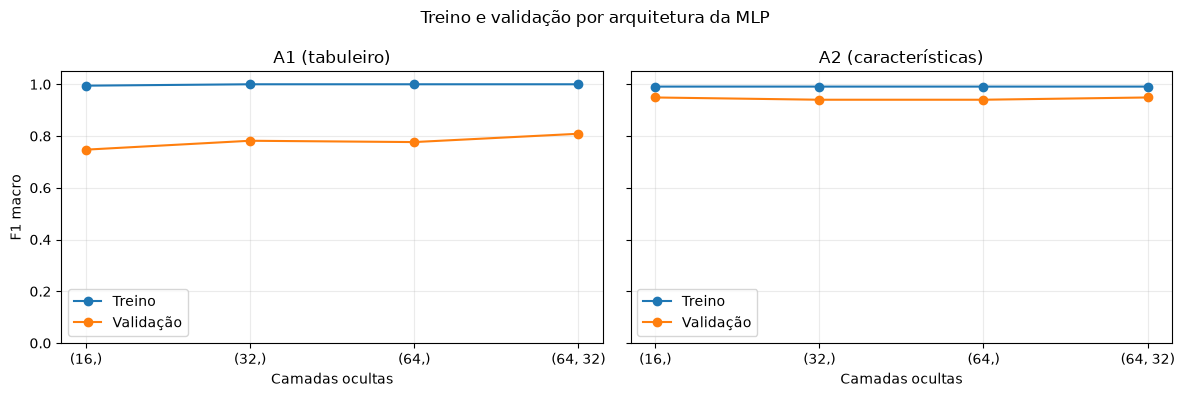

In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for eixo, ab in zip(eixos, abordagens):
    linhas = resultados[(resultados["codigo_abordagem"] == ab) & resultados["convergiu"]]
    linhas = linhas.sort_values(
        ["val_f1_macro", "val_acc", "n_parametros", "alpha"],
        ascending=[False, False, True, False], kind="stable",
    ).drop_duplicates("camadas").set_index("camadas")
    ordem = [str(camadas) for camadas in lista_camadas if str(camadas) in linhas.index]
    linhas = linhas.loc[ordem]
    eixo.plot(ordem, linhas["f1_treino"], marker="o", label="Treino")
    eixo.plot(ordem, linhas["val_f1_macro"], marker="o", label="Validação")
    eixo.set(title=abordagens[ab], xlabel="Camadas ocultas", ylim=(0, 1.05))
    eixo.grid(alpha=0.25)
    eixo.legend()
eixos[0].set_ylabel("F1 macro")
fig.suptitle("Treino e validação por arquitetura da MLP")
fig.tight_layout()
figuras["treino_validacao"] = fig
plt.show()

## 12. Avaliar as configurações selecionadas no teste e medir custo

Nesta etapa, o conjunto de teste avalia as duas configurações selecionadas pela validação.
Seus resultados não são utilizados para alterar a grade, os parâmetros ou a abordagem recomendada.

Medimos a média e o desvio padrão de 20 ajustes com os parâmetros fixados e de 20
previsões sobre o lote de 93 tabuleiros. As repetições têm finalidade de medição de tempo;
o modelo avaliado é o preservado durante a busca. Limitamos o paralelismo a uma thread
para tornar as medições mais controladas.

Os tempos incluem a padronização e o ajuste ou a previsão do classificador. A leitura dos
CSVs e a extração das características a partir de um tabuleiro não fazem parte dessas
medições, pois as duas representações já estão disponíveis nos arquivos preparados.
Assim, os valores descrevem o custo do processamento pelo modelo, não o tempo completo do front end.

`tempo_pred_ms` representa a previsão de **todo o lote**. O tempo por tabuleiro é a média
amortizada desse lote, obtida por divisão por 93; não corresponde à medição de uma chamada
individual. Hardware, versões, paralelismo e carga do computador influenciam os tempos.
A comparação entre algoritmos deve considerar essas condições de execução.

In [11]:
REPETICOES_TEMPO = 20
tabela = []
previsoes = {}

for ab, info in melhor.items():
    d = dados[ab]
    modelo = info["modelo"]
    print(f"Medindo custo e avaliando {abordagens[ab]}...", flush=True)
    duracoes_treino = []
    with threadpool_limits(limits=1):
        for _ in range(REPETICOES_TEMPO):
            novo_modelo = criar_modelo(**info["params"])
            inicio = time.perf_counter()
            avisos = ajustar_modelo(novo_modelo, d["X_train"], d["y_train"])
            duracoes_treino.append((time.perf_counter() - inicio) * 1000)
            if avisos:
                raise RuntimeError(f"Convergência mudou na medição de tempo: {avisos}")
        duracoes_pred = []
        for _ in range(REPETICOES_TEMPO):
            inicio = time.perf_counter()
            modelo.predict(d["X_test"])
            duracoes_pred.append((time.perf_counter() - inicio) * 1000)
        previsoes[ab] = modelo.predict(d["X_test"])

    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "acuracia": m["acc"], "precision": m["precision"],
        "recall": m["recall"], "f1_macro": m["f1_macro"],
        "gap_treino_val": info["metricas_treino"]["f1_macro"] - info["metricas_validacao"]["f1_macro"],
        "tempo_treino_ms": float(np.mean(duracoes_treino)),
        "tempo_treino_desvio_ms": float(np.std(duracoes_treino)),
        "tempo_pred_ms": float(np.mean(duracoes_pred)),
        "tempo_pred_desvio_ms": float(np.std(duracoes_pred)),
        "tempo_pred_por_tabuleiro_ms": float(np.mean(duracoes_pred)) / len(d["X_test"]),
    })

tabela = pd.DataFrame(tabela)
tabela.round(4)

Medindo custo e avaliando A1 (tabuleiro)...
Medindo custo e avaliando A2 (características)...


,codigo_abordagem,abordagem,acuracia,precision,recall,f1_macro,gap_treino_val,tempo_treino_ms,tempo_treino_desvio_ms,tempo_pred_ms,tempo_pred_desvio_ms,tempo_pred_por_tabuleiro_ms
0,abordagem_1,A1 (tabuleiro),0.8495,0.7224,0.7333,0.7166,0.1913,1143.2838,57.2134,1.0070,1.9000,0.0108
1,abordagem_2,A2 (características),0.9140,0.9329,0.9333,0.9327,0.0420,1098.6068,136.0134,0.4413,0.1284,0.0047


## 13. Examinar métricas por classe

A média macro resume as quatro classes, mas o relatório por classe mostra quais estados
a rede acerta e onde erra. **Suporte (support)** é a quantidade de exemplos reais daquela classe no conjunto avaliado.
No teste há somente três empates: acertar ou errar um muda bastante o recall dessa classe.
Não interpretamos uma pontuação alta nesse grupo como prova de desempenho estável.

In [12]:
relatorios = {}
for ab in abordagens:
    print("\n", abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
                                zero_division=0, digits=3))
    relatorios[ab] = classification_report(
        dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
        zero_division=0, output_dict=True,
    )


 A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo      0.900     0.600     0.720        30
Jogador X venceu      0.882     1.000     0.938        30
Jogador O venceu      0.857     1.000     0.923        30
          Empate      0.250     0.333     0.286         3

        accuracy                          0.849        93
       macro avg      0.722     0.733     0.717        93
    weighted avg      0.860     0.849     0.842        93


 A2 (características)
                  precision    recall  f1-score   support

        Tem jogo      0.893     0.833     0.862        30
Jogador X venceu      0.871     0.900     0.885        30
Jogador O venceu      0.968     1.000     0.984        30
          Empate      1.000     1.000     1.000         3

        accuracy                          0.914        93
       macro avg      0.933     0.933     0.933        93
    weighted avg      0.913     0.914     0.913        93



## 14. Visualizar os erros na matriz de confusão

As linhas são as classes reais e as colunas são as classes previstas. A diagonal contém
os acertos; os valores fora da diagonal mostram quais estados foram confundidos.
Por exemplo, uma vitória prevista como **Tem jogo** seria um erro relevante na interação.

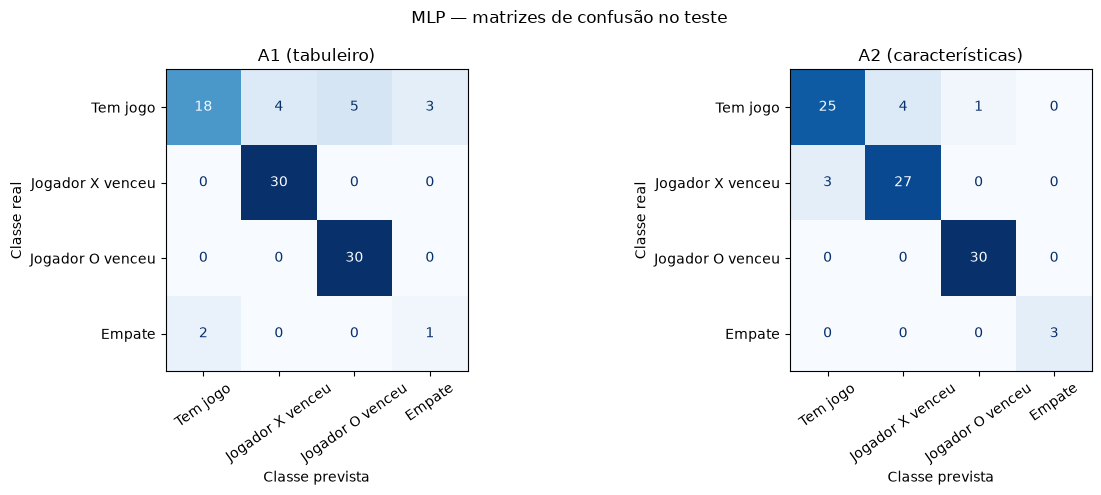

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
for eixo, ab in zip(eixos, abordagens):
    ConfusionMatrixDisplay.from_predictions(
        dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
        display_labels=CLASSES, ax=eixo, colorbar=False, cmap="Blues", xticks_rotation=35,
    )
    eixo.set(title=abordagens[ab], xlabel="Classe prevista", ylabel="Classe real")
fig.suptitle("MLP — matrizes de confusão no teste")
fig.tight_layout()
figuras["matrizes_confusao"] = fig
plt.show()

## 15. Comparar desempenho e custo das abordagens

O primeiro gráfico compara as quatro métricas no teste. O segundo mostra os tempos de
treinamento e previsão em eixos separados, pois suas escalas são muito diferentes.
O número de características, o tamanho da rede e as iterações do otimizador influenciam
o custo; menos entradas não garantem automaticamente menor tempo de treino.

Esta comparação avalia as abordagens **com a MLP**. A escolha do algoritmo para a aplicação considera a comparação dos cinco classificadores.

A comparação consolidada e a escolha do SVM estão no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).


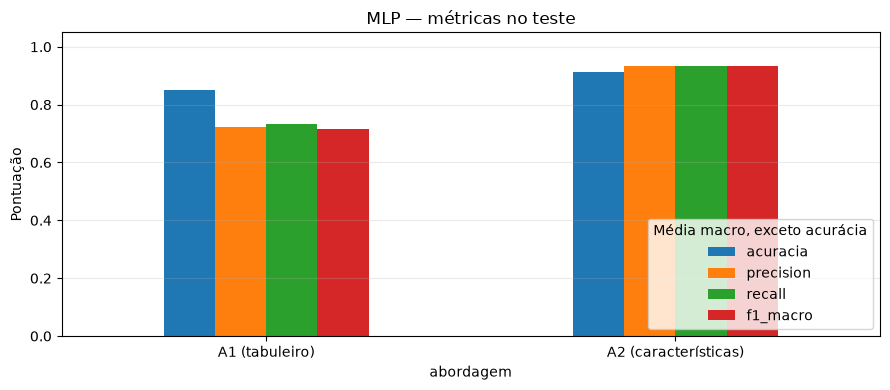

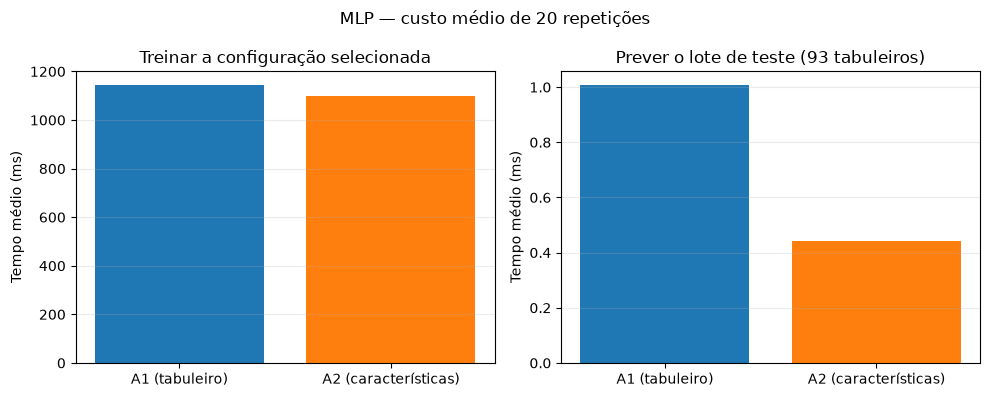

In [14]:
fig, eixo = plt.subplots(figsize=(9, 4))
tabela.set_index("abordagem")[["acuracia", "precision", "recall", "f1_macro"]].plot.bar(ax=eixo)
eixo.set(title="MLP — métricas no teste", ylabel="Pontuação", ylim=(0, 1.05))
eixo.tick_params(axis="x", rotation=0)
eixo.legend(title="Média macro, exceto acurácia", loc="lower right")
eixo.grid(axis="y", alpha=0.25)
fig.tight_layout()
figuras["metricas_teste"] = fig
plt.show()

fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for eixo, coluna, titulo in zip(
    eixos, ["tempo_treino_ms", "tempo_pred_ms"],
    ["Treinar a configuração selecionada", "Prever o lote de teste (93 tabuleiros)"],
):
    eixo.bar(tabela["abordagem"], tabela[coluna], color=["tab:blue", "tab:orange"])
    eixo.set(title=titulo, ylabel="Tempo médio (ms)")
    eixo.grid(axis="y", alpha=0.25)
fig.suptitle(f"MLP — custo médio de {REPETICOES_TEMPO} repetições")
fig.tight_layout()
figuras["custo"] = fig
plt.show()

## 16. Documentar a conclusão do experimento

O texto a seguir é montado com os resultados desta execução. Ele registra a escolha feita
pela validação, a topologia, as métricas de teste e os limites da análise.
Uma diferença acentuada entre os resultados de treino e validação deve ser discutida
como possível indício de sobreajuste, mesmo quando as métricas de teste são favoráveis.

A comparação consolidada e a escolha do SVM estão no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).


In [15]:
conclusoes = []
for ab in abordagens:
    s = selecao.loc[selecao["codigo_abordagem"] == ab].iloc[0]
    t = tabela.loc[tabela["codigo_abordagem"] == ab].iloc[0]
    conclusoes.append(
        f"**{abordagens[ab]}:** topologia **{s['topologia']}**, ativação `{s['ativacao']}`, "
        f"alpha={s['alpha']:g} e {s['n_parametros']} parâmetros. "
        f"F1 macro: treino {s['f1_treino']:.3f}, validação {s['val_f1_macro']:.3f} "
        f"e teste {t['f1_macro']:.3f}; acurácia no teste {t['acuracia']:.1%}. "
        f"Diferença treino–validação: {s['gap_treino_val']:.3f}. "
        f"Treino médio: {t['tempo_treino_ms']:.2f} ms; "
        f"previsão do lote: {t['tempo_pred_ms']:.3f} ms."
    )

vencedora = selecao.loc[selecao["codigo_abordagem"] == ab_escolhida].iloc[0]
mais_rapida_treino = tabela.loc[tabela["tempo_treino_ms"].idxmin(), "abordagem"]
mais_rapida_pred = tabela.loc[tabela["tempo_pred_ms"].idxmin(), "abordagem"]
texto_conclusao = (
    "\n\n".join(conclusoes)
    + f"\n\n**Recomendação para a MLP:** {abordagens[ab_escolhida]}, escolhida antes do teste "
      f"pelo F1 macro de validação ({vencedora['val_f1_macro']:.3f}) e pelos critérios de desempate. "
      f"Nesta medição, {mais_rapida_treino} teve menor tempo médio de treino e "
      f"{mais_rapida_pred} teve menor tempo médio de previsão. Diferenças pequenas de tempo "
      "podem oscilar entre execuções."
    + "\n\n**Limitações:** somente dois empates na validação e três no teste; "
      "reamostragem não cria novos empates; possíveis simetrias entre divisões; "
      "entradas iguais com rótulos diferentes na abordagem 2; busca finita e apenas uma semente. "
      "Estes resultados não demonstram ausência de overfitting nem garantem generalização "
      "para qualquer partida. A avaliação durante partidas com usuários deve ser registrada separadamente no front end\ne apresentada no relatório, pois mede uma situação de uso diferente do teste reservado."
)
maior_gap = selecao.loc[selecao["gap_treino_val"].idxmax()]
analise = (
    f"\n\n**Interpretação da generalização:** {maior_gap['abordagem']} teve a maior diferença "
    f"entre F1 de treino ({maior_gap['f1_treino']:.3f}) e validação "
    f"({maior_gap['val_f1_macro']:.3f}). Essa queda é um indício de possível overfitting "
    "e deve ser discutida mesmo com regularização. "
    "Uma diferença menor na outra abordagem é favorável, mas não demonstra ausência de overfitting."
)
for ab in abordagens:
    empates = relatorios[ab]["Empate"]
    quantidade = int(round(empates["recall"] * empates["support"]))
    analise += f" {abordagens[ab]} reconheceu {quantidade} dos {int(empates['support'])} empates do teste."
texto_conclusao = texto_conclusao.replace("\n\n**Limitações:**", analise + "\n\n**Limitações:**")
display(Markdown(texto_conclusao))

**A1 (tabuleiro):** topologia **9 → 64 → 32 → 4**, ativação `relu`, alpha=1 e 2852 parâmetros. F1 macro: treino 1.000, validação 0.809 e teste 0.717; acurácia no teste 84.9%. Diferença treino–validação: 0.191. Treino médio: 1143.28 ms; previsão do lote: 1.007 ms.

**A2 (características):** topologia **15 → 64 → 32 → 4**, ativação `relu`, alpha=1 e 3236 parâmetros. F1 macro: treino 0.991, validação 0.949 e teste 0.933; acurácia no teste 91.4%. Diferença treino–validação: 0.042. Treino médio: 1098.61 ms; previsão do lote: 0.441 ms.

**Recomendação para a MLP:** A2 (características), escolhida antes do teste pelo F1 macro de validação (0.949) e pelos critérios de desempate. Nesta medição, A2 (características) teve menor tempo médio de treino e A2 (características) teve menor tempo médio de previsão. Diferenças pequenas de tempo podem oscilar entre execuções.

**Interpretação da generalização:** A1 (tabuleiro) teve a maior diferença entre F1 de treino (1.000) e validação (0.809). Essa queda é um indício de possível overfitting e deve ser discutida mesmo com regularização. Uma diferença menor na outra abordagem é favorável, mas não demonstra ausência de overfitting. A1 (tabuleiro) reconheceu 1 dos 3 empates do teste. A2 (características) reconheceu 3 dos 3 empates do teste.

**Limitações:** somente dois empates na validação e três no teste; reamostragem não cria novos empates; possíveis simetrias entre divisões; entradas iguais com rótulos diferentes na abordagem 2; busca finita e apenas uma semente. Estes resultados não demonstram ausência de overfitting nem garantem generalização para qualquer partida. A avaliação durante partidas com usuários deve ser registrada separadamente no front end
e apresentada no relatório, pois mede uma situação de uso diferente do teste reservado.

## 17. Salvar os resultados e o modelo com seu pré-processamento

Salvamos a grade avaliada, a seleção, as métricas, as previsões individuais, os relatórios
por classe e os gráficos. O JSON registra parâmetros, versões e hashes dos CSVs para
identificar os dados usados. A conclusão fica também em Markdown.

O arquivo `modelo_mlp.joblib` contém o **Pipeline completo** da abordagem escolhida,
incluindo o padronizador ajustado no treino. Para usá-lo, as entradas devem ter as mesmas
colunas, na mesma ordem, e a mesma representação; `id_tabuleiro` e `estado` não entram.
O modelo exportado é o que foi avaliado, sem novo treino com validação/teste.

In [16]:
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
resultados.to_csv(PASTA_RESULTADOS / "busca_validacao.csv", index=False)
selecao.to_csv(PASTA_RESULTADOS / "configuracoes_selecionadas.csv", index=False)
tabela.to_csv(PASTA_RESULTADOS / "metricas_teste.csv", index=False)

linhas_predicoes = []
for ab in abordagens:
    linhas_predicoes.append(pd.DataFrame({
        "abordagem": ab,
        "id_tabuleiro": dados[ab]["ids_test"].to_numpy(),
        "estado_real": dados[ab]["y_test"],
        "estado_previsto": previsoes[ab],
        "acertou": dados[ab]["y_test"] == previsoes[ab],
    }))
pd.concat(linhas_predicoes, ignore_index=True).to_csv(PASTA_RESULTADOS / "previsoes_teste.csv", index=False)
(PASTA_RESULTADOS / "relatorios_por_classe.json").write_text(
    json.dumps(relatorios, ensure_ascii=False, indent=2), encoding="utf-8",
)

resumo = {
    "semente": SEED, "versoes": versoes,
    "plataforma": platform.platform(), "threads_blas": 1,
    "classes": CLASSES, "criterio_selecao": "F1 macro de validação; acurácia; menos parâmetros; maior alpha",
    "parametros_fixos": PARAMETROS_FIXOS,
    "grade": {"camadas": lista_camadas, "ativacao": lista_ativacao, "alpha": lista_alpha},
    "configuracoes_testadas": len(resultados),
    "avisos_convergencia": int((~resultados["convergiu"]).sum()),
    "abordagem_escolhida_pela_validacao": ab_escolhida,
    "configuracoes_selecionadas": {ab: info["params"] for ab, info in melhor.items()},
    "features_modelo_exportado": list(dados[ab_escolhida]["X_train"].columns),
    "ordem_saidas_modelo": list(melhor[ab_escolhida]["modelo"].named_steps["mlpclassifier"].classes_),
    "repeticoes_tempo": REPETICOES_TEMPO,
    "csvs_entrada_sha256": {
        str(caminho.relative_to(RAIZ)): hashlib.sha256(caminho.read_bytes()).hexdigest()
        for caminho in arquivos_entrada
    },
}
(PASTA_RESULTADOS / "resumo_experimento.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2), encoding="utf-8",
)
(PASTA_RESULTADOS / "conclusao.md").write_text(texto_conclusao + "\n", encoding="utf-8")

for nome, figura in figuras.items():
    figura.savefig(PASTA_RESULTADOS / f"{nome}.png", dpi=150, bbox_inches="tight")
joblib.dump(melhor[ab_escolhida]["modelo"], PASTA_RESULTADOS / "modelo_mlp.joblib")

print("Arquivos salvos em:", PASTA_RESULTADOS.relative_to(RAIZ))
for caminho in sorted(PASTA_RESULTADOS.iterdir()):
    print(" -", caminho.name)

Arquivos salvos em: dataset/processado/mlp/resultados
 - busca_validacao.csv
 - conclusao.md
 - configuracoes_selecionadas.csv
 - custo.png
 - matrizes_confusao.png
 - metricas_teste.csv
 - metricas_teste.png
 - modelo_mlp.joblib
 - previsoes_teste.csv
 - relatorios_por_classe.json
 - resumo_experimento.json
 - treino_validacao.png
